In [20]:
# 221900180 田永铭
# 说明：Iris数据集在训练集占百分之70的时候，准确率是97.78%；训练集占百分之80的时候，测试集准确度能达到100%。

# 在这份代码中我完成了：
# 1.数据预处理（包括缺失值处理和数据标准化）
# 2.自己编写的朴素贝叶斯实现，并且和sklearn包里的GaussianNB进行了对比，发现高度一致
# 3.数据的混淆矩阵可视化以及pca降维可视化
# 4.其它数据集上该方法的测试，wine数据集上准确率1.0，breast_cancer数据集上准确率0.96
# 5.调参获得了更大的准确度
# 6.除了准确率，还考察了F1-score等其它指标

In [21]:
# 导入各种包
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine, load_breast_cancer


# 载入数据集，采用的是load_iris方式
def load_data(use_sklearn=True):
    data = load_iris() # 准确率1.0
    # data = load_wine() 准确率1.0
    # data = load_breast_cancer() 准确率0.96
    X, y = data.data, data.target
    return X, y

In [22]:
# 数据预处理
def preprocess_data(X):
    # 检查缺失值并填充
    if np.isnan(X).any():
        X = np.nan_to_num(X)
    # 数据标准化
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    return X

In [23]:
# 自己定义的朴素贝叶斯实现（最终效果和包里的类似）
class NaiveBayesClassifier:
    def train(self, data, targets):
        self.categories = np.unique(targets)  # 获取所有唯一类别
        self.category_means = {}  # 存储均值
        self.category_vars = {}   # 存储方差
        self.category_priors = {}  # 存储先验概率

        for category in self.categories:
            data_for_category = data[targets == category]  # 获取当前类别的数据
            self.category_means[category] = data_for_category.mean(axis=0)  # 计算均值
            self.category_vars[category] = data_for_category.var(axis=0)    # 计算方差
            self.category_priors[category] = data_for_category.shape[0] / data.shape[0]  # 计算先验概率

    def classify(self, data):
        results = [self._classify_single(sample) for sample in data]  # 逐个分类
        return np.array(results)  # 返回所有分类结果

    def _classify_single(self, sample):
        posterior_probs = []  # 存储后验概率
        for category in self.categories:
            prior_log = np.log(self.category_priors[category])  # 取对数
            likelihood_log = np.sum(np.log(self._compute_pdf(category, sample)))  # 类条件概率的对数
            posterior = prior_log + likelihood_log  # 计算后验概率
            posterior_probs.append(posterior)  # 添加后验概率
        return self.categories[np.argmax(posterior_probs)]  # 返回最大后验概率的类别

    def _compute_pdf(self, category, sample):
        mean = self.category_means[category]  # 获取均值
        var = self.category_vars[category]  # 获取方差
        numerator = np.exp(- (sample - mean) ** 2 / (2 * var))  # PDF的分子
        denominator = np.sqrt(2 * np.pi * var)  # PDF的分母
        return numerator / denominator  # 返回概率密度值

In [24]:
# 加载数据
X, y = load_data(use_sklearn=True)

# 数据预处理
X = preprocess_data(X)

# 划分训练集和测试集
# ！为了后面可视化效果更好，可以把测试集比例提高到0.3，这样更好看；或者采取load_breast_cancer数据集亦可
# 而测试集比例在0.2的时候能达到100%准确率
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [25]:
# 训练模型
model = NaiveBayesClassifier()
model.train(X_train, y_train)

# 预测测试集
y_pred = model.classify(X_test)

# 计算准确率
accuracy = np.mean(y_pred == y_test)
# 打印准确率
print(f"Accuracy: {accuracy:.6f}")

# 打印F1-score和回归率
# 计算并打印F1-score和召回率
from sklearn.metrics import f1_score, recall_score

f1 = f1_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
print(f"F1-score: {f1:.6f}")
print(f"Recall: {recall:.6f}")

Accuracy: 0.977778
F1-score: 0.977745
Recall: 0.977778


In [26]:
# 使用scikit-learn的GaussianNB进行比较
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_sklearn = gnb.predict(X_test)
accuracy_sklearn = np.mean(y_pred_sklearn == y_test)
print(f"Scikit-learn GaussianNB Accuracy: {accuracy_sklearn:.2f}")

Scikit-learn GaussianNB Accuracy: 0.98


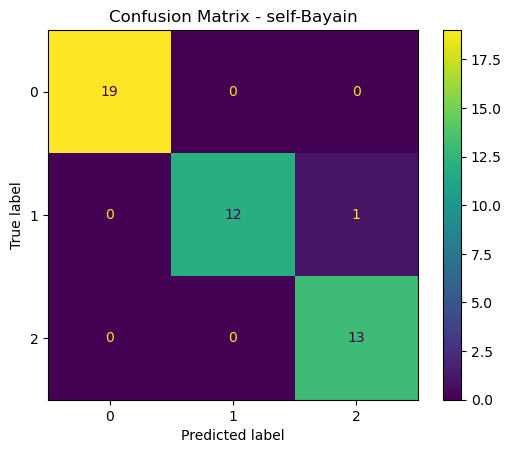

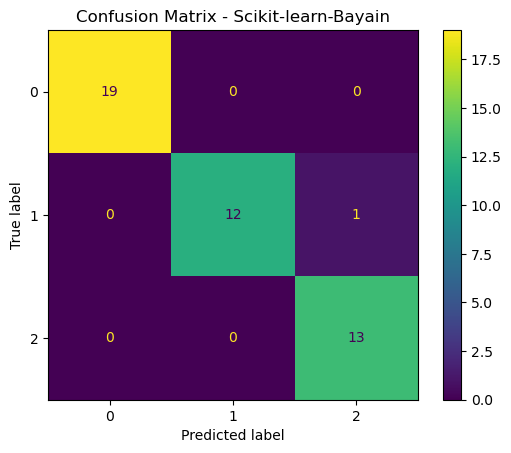

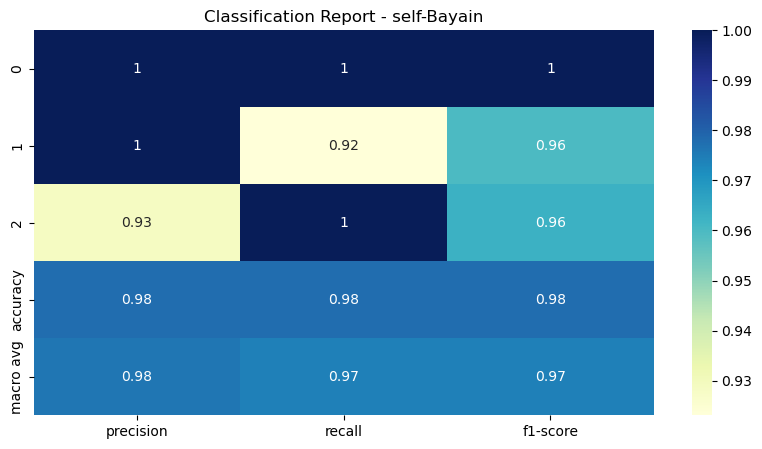

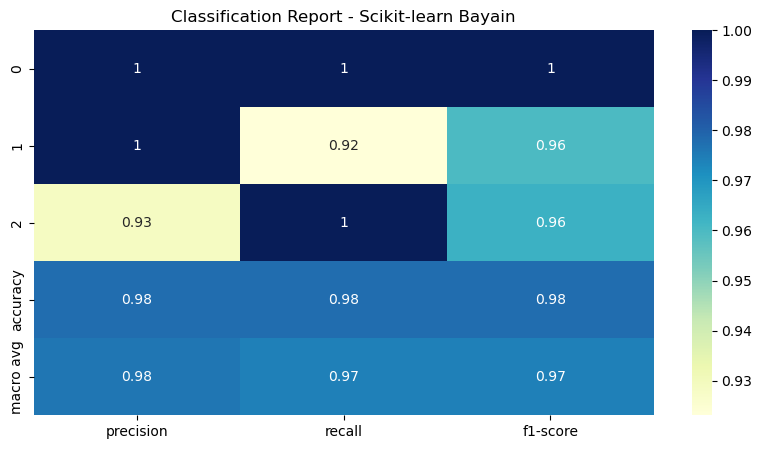

In [27]:
#训练结果可视化 

#导入包
import seaborn as sns
from sklearn.metrics import classification_report
# 计算混淆矩阵
cm = confusion_matrix(y_test, y_pred)
cm_sklearn = confusion_matrix(y_test, y_pred_sklearn)

# 显示自定义NaiveBayesClassifier的混淆矩阵
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - self-Bayain")
plt.show()

# 显示Scikit-learn GaussianNB的混淆矩阵
disp_sklearn = ConfusionMatrixDisplay(confusion_matrix=cm_sklearn)
disp_sklearn.plot()
plt.title("Confusion Matrix - Scikit-learn-Bayain")
plt.show()

# 可视化分类报告
report = classification_report(y_test, y_pred, output_dict=True)
report_sklearn = classification_report(y_test, y_pred_sklearn, output_dict=True)

# 将分类报告转换为DataFrame
df_report = pd.DataFrame(report).transpose()
df_report_sklearn = pd.DataFrame(report_sklearn).transpose()

# 绘制分类报告的热力图
plt.figure(figsize=(10, 5))
sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap="YlGnBu")
plt.title("Classification Report - self-Bayain")
plt.show()

plt.figure(figsize=(10, 5))
sns.heatmap(df_report_sklearn.iloc[:-1, :-1], annot=True, cmap="YlGnBu")
plt.title("Classification Report - Scikit-learn Bayain")
plt.show()

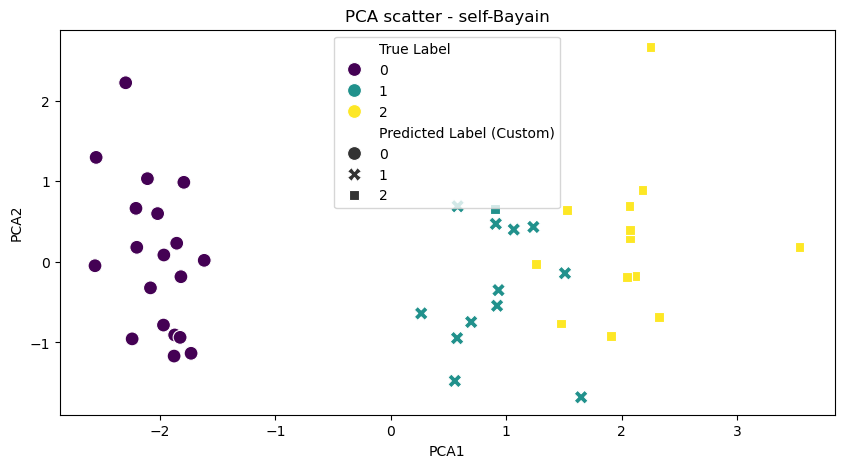

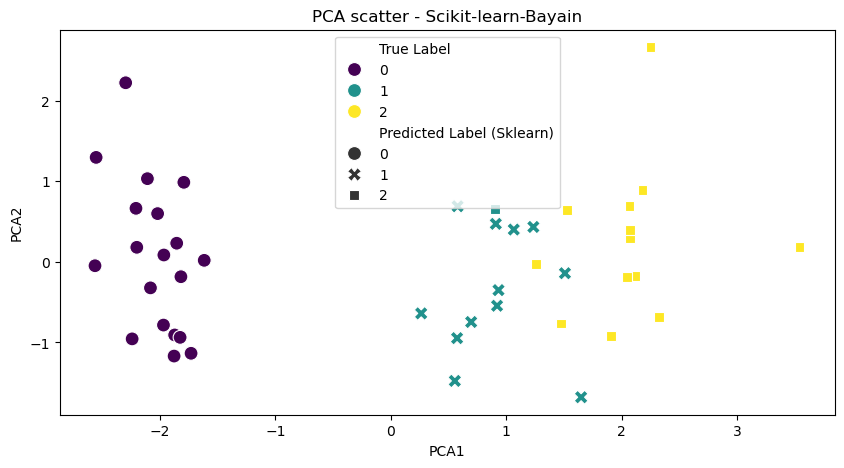

In [28]:

from sklearn.decomposition import PCA

# 使用PCA将数据降维到2D
pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test)

# 创建一个DataFrame来存储PCA结果和预测标签
df_pca = pd.DataFrame(X_test_pca, columns=['PCA1', 'PCA2'])
df_pca['True Label'] = y_test
df_pca['Predicted Label (Custom)'] = y_pred
df_pca['Predicted Label (Sklearn)'] = y_pred_sklearn

# 绘制自定义NaiveBayesClassifier的PCA点图
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_pca, x='PCA1', y='PCA2', hue='True Label', style='Predicted Label (Custom)', palette='viridis', s=100)
plt.title("PCA scatter - self-Bayain")
plt.show()

# 绘制Scikit-learn GaussianNB的PCA点图
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_pca, x='PCA1', y='PCA2', hue='True Label', style='Predicted Label (Sklearn)', palette='viridis', s=100)
plt.title("PCA scatter - Scikit-learn-Bayain")
plt.show()